In [24]:
from transformers import AutoProcessor, AutoModelForImageTextToText
from models.latent_student import LatentStudent
from datasets import load_dataset
import torch
from huggingface_hub import HfApi
import matplotlib.pyplot as plt
import numpy as np

In [2]:
processor = AutoProcessor.from_pretrained("shreethar/LatentStudent-ckpt-240")

In [100]:
processor.tokenizer.convert_ids_to_tokens(248048)

'<|object_ref_end|>'

In [82]:
processor.tokenizer.convert_tokens_to_ids("</think>")

248069

In [3]:
end_think_token_id = processor.tokenizer.convert_tokens_to_ids("</think>")

In [4]:
student = LatentStudent.from_pretrained("shreethar/LatentStudent-ckpt-240", end_think_token_id = end_think_token_id)

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

Successfully loaded spatial parameters from shreethar/LatentStudent-ckpt-240


In [5]:
student = student.cuda().eval()

In [6]:
dataset = load_dataset("shreethar/FYP-Stage2-dataset", split = "train")

Resolving data files:   0%|          | 0/167 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/167 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/151 [00:00<?, ?it/s]

In [59]:
data = dataset[3]

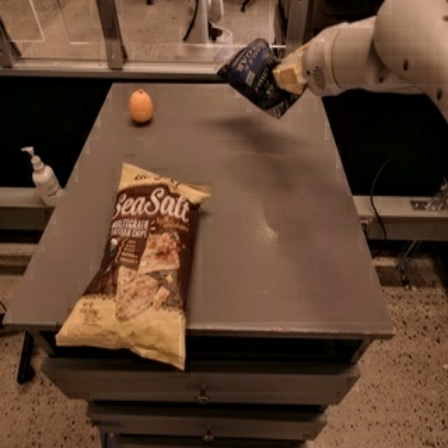

In [61]:
data['frames'][0]

In [62]:
human = data['human']
images = data['frames'][0]

In [63]:
message = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": images
            },
            {
                "type": "text",
                "text": human
            }
        ]
    }
]

In [64]:
input_text = processor.apply_chat_template(
    message,
    tokenize = False,
    add_generation_prompt = True,
    return_dict = True,
    enable_thinking = True
)

In [65]:
print(input_text)

<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>You are a robot manipulation assistant. Given an observation image and a task instruction, predict the end-effector's 2D trajectory as 5 waypoints. Output ONLY the coordinate list in this exact format: [[x1,y1],[x2,y2],[x3,y3],[x4,y4],[x5,y5]]

Task: The task is move blue chip bag near orange. What is the trajectory that the end effector should take?<|im_end|>
<|im_start|>assistant
<think>



In [66]:
inputs = processor.apply_chat_template(
    message,
    tokenize = True,
    add_generation_prompt = True,
    return_dict = True,
    enable_thinking = True,
    return_tensors = "pt"
).to("cuda")

In [67]:
with torch.no_grad():
    latents, h_s, spatial_hidden, waypoints = student.generate_latents(
        input_ids = inputs.input_ids,
        pixel_values = inputs.pixel_values,
        image_grid_thw = inputs.image_grid_thw,
        attention_mask = inputs.attention_mask
    )

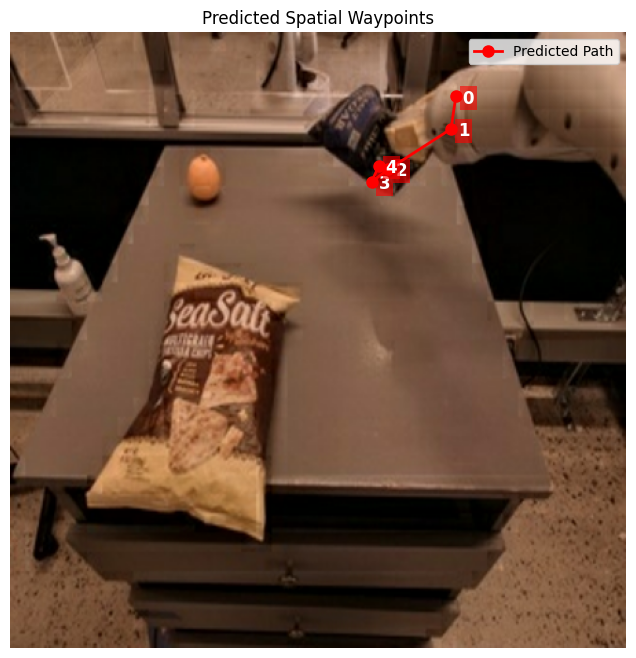

In [68]:
# 1. Detach the tensor, move to CPU, and convert to numpy
# waypoints shape is [1, 5, 2], so we take [0] to get the (5, 2) array
waypoints_np = waypoints.detach().cpu().to(torch.float32).numpy()[0] 

# 2. Get image dimensions to denormalize the coordinates
# If it's a PIL Image:
if hasattr(images, 'size'):
    width, height = images.size
# If it's a numpy array or PyTorch tensor:
else:
    height, width = np.array(images).shape[:2]

# 3. Denormalize coordinates: [x, y] * [width, height]
x_coords = waypoints_np[:, 0] * width
y_coords = waypoints_np[:, 1] * height

# 4. Plot the image and overlay the waypoints
plt.figure(figsize=(10, 8))
plt.imshow(images)

# Draw the path (lines connecting the waypoints)
plt.plot(x_coords, y_coords, marker='o', color='red', markersize=8, linewidth=2, label='Predicted Path')

# Number each waypoint to see the sequence order (0 to 4)
for i, (x, y) in enumerate(zip(x_coords, y_coords)):
    plt.text(x + max(width*0.01, 5), y + max(height*0.01, 5), str(i), 
             color='white', fontsize=12, weight='bold',
             bbox=dict(facecolor='red', alpha=0.6, pad=2, edgecolor='none'))

plt.legend()
plt.axis('off') # Hide axes for cleaner look
plt.title('Predicted Spatial Waypoints')
plt.show()


In [25]:
teacher = AutoModelForImageTextToText.from_pretrained("shreethar/stage2_teacher", dtype = torch.bfloat16, device_map="cuda")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/9.08G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

In [69]:
with torch.no_grad():
    output = teacher.generate(
        **inputs,
        max_new_tokens = 512
    )

In [70]:
print(processor.tokenizer.decode(output[0]))

<|im_start|>user
<|vision_start|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|ima

In [41]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_teacher_waypoints(image, waypoints_list):
    # Convert image to array to safely get height (h) and width (w)
    img_array = np.array(image)
    h, w = img_array.shape[:2]

    # Convert the list to a numpy array and normalize by 1000
    pts = np.array(waypoints_list, dtype=np.float32) / 1000.0

    # Scale the [0, 1] coordinates to the image's absolute pixels
    x_coords = pts[:, 0] * w
    y_coords = pts[:, 1] * h

    # Create the visualization
    plt.figure(figsize=(10, 8))
    plt.imshow(img_array)

    # Plot lines and markers
    plt.plot(x_coords, y_coords, marker='s', color='cyan', markersize=8, linewidth=2, label='Teacher Path')

    # Add step numbers (0 to 4) next to each waypoint
    for i, (x, y) in enumerate(zip(x_coords, y_coords)):
        plt.text(x + max(w * 0.01, 5), y + max(h * 0.01, 5), str(i), 
                 color='black', fontsize=12, weight='bold',
                 bbox=dict(facecolor='cyan', alpha=0.7, pad=2, edgecolor='none'))

    plt.legend()
    plt.axis('off')
    plt.title('Teacher Waypoints')
    plt.show()

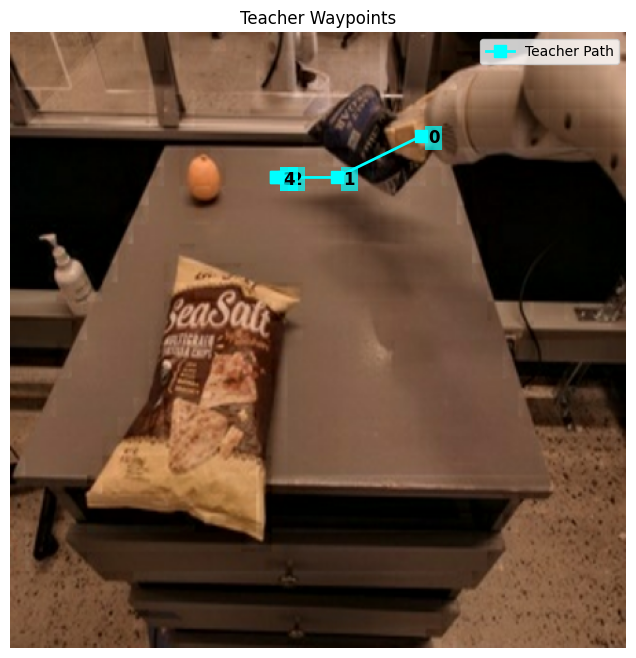

In [71]:
teacher_output = [[666,168],[529,235],[443,235],[431,235],[431,235]]
visualize_teacher_waypoints(images, teacher_output)

In [50]:
base_model = AutoModelForImageTextToText.from_pretrained(
    "unsloth/Qwen3.5-4B",
    dtype = torch.bfloat16,
    device_map = "cuda"
)

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

In [72]:
inputs = processor.apply_chat_template(
    message,
    tokenize = True,
    add_generation_prompt = True,
    return_dict = True,
    enable_thinking = False,
    return_tensors = "pt"
).to("cuda")

In [73]:
with torch.no_grad():
    output = base_model.generate(
        **inputs,
        max_new_tokens = 512
    )

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


In [74]:
print(processor.tokenizer.decode(output[0]))

<|im_start|>user
<|vision_start|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|ima

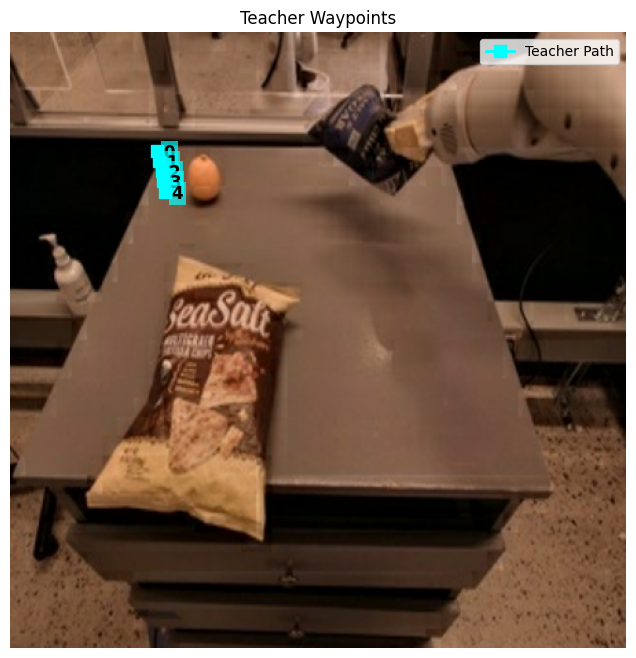

In [75]:
base_output = [[237, 192], [241, 208], [245, 225], [247, 241], [250, 258]]
visualize_teacher_waypoints(images, base_output)

In [54]:
stage1 = AutoModelForImageTextToText.from_pretrained(
    "shreethar/stage1_unsloth",
    dtype = torch.bfloat16,
    device_map = "cuda"
)

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

In [76]:
with torch.no_grad():
    output = stage1.generate(
        **inputs,
        max_new_tokens = 512
    )

In [77]:
print(processor.tokenizer.decode(output[0]))

<|im_start|>user
<|vision_start|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|ima

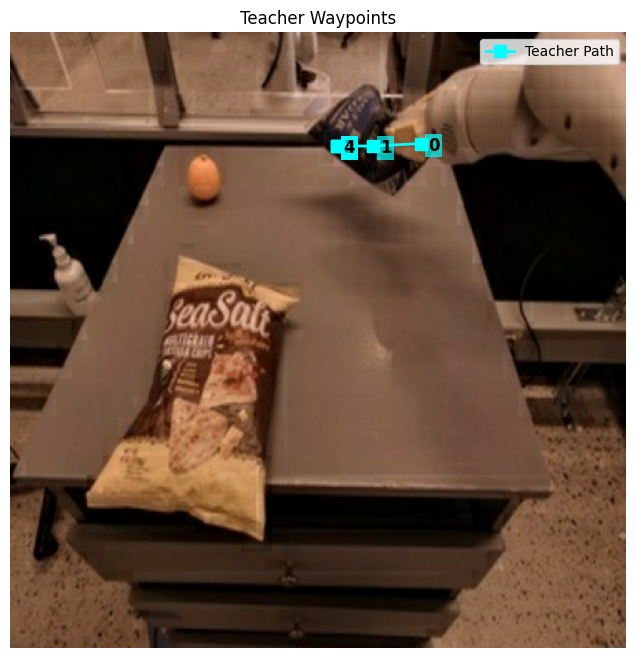

In [78]:
stage1_output = [[666,180],[588,184],[529,184],[529,184],[529,184]]
visualize_teacher_waypoints(images, stage1_output)